
# **Brake Pad Design Optimization: Gaussian Process Surrogate Modeling**

This study develops a high-fidelity surrogate model to predict **Braking Torque** as a function of four critical design parameters: **Cocopeat Percentage**, **Inner Diameter**, **Actuation Force**, and **Sweep Angle**. By employing Gaussian Process Regression (GPR), we capture non-linear interactions and quantify prediction uncertainty across the design space.
```

In [1]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 45.4 MB/s  0:00:006m0:00:01

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 43.7 MB/s  0:00:006m0:00:01

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 48.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 41.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 45.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip insta

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

# The `!head` command revealed that the file uses commas as a delimiter
# and contains comment lines starting with '#'.
# We will use `comment='#'` to skip these lines and allow `pd.read_csv`
# to use its default comma separator.
#!head '/content/drive/MyDrive/Colab Notebooks/BrakePadOptm/FivePercentCocopeat.csv'

data1 = pd.read_csv('FivePercentCocopeat.csv', comment='#')
# Rename the 'Name' column to 'percentage' and set its value to '5'
data1 = data1.drop(columns=['P10', 'P11','P14','P15'])
data1 = data1.rename(columns={'Name': 'percentage','P1': 'InnerDiameter','P7':'ActuationForce','P9':'SweepAngle',
                              'P5':'MaxEquivStress','P6':'MaxEquivPlastStrain','P16':'BrakingTorque'})
data1['percentage'] = 5.0
data1['SweepAngle'] = 180.0-2.0*data1['SweepAngle']
print(data1.head())

data2 = pd.read_csv('TenPercentCocopeat.csv', comment='#')
# Rename the 'Name' column to 'percentage' and set its value to '10'
data2 = data2.drop(columns=['P10', 'P11','P14','P15'])
data2 = data2.rename(columns={'Name': 'percentage','P1': 'InnerDiameter','P7':'ActuationForce','P9':'SweepAngle',
                              'P5':'MaxEquivStress','P6':'MaxEquivPlastStrain','P16':'BrakingTorque'})
data2['percentage'] = 10.0
data2['SweepAngle'] = 180.0-2.0*data2['SweepAngle']
print(data2.head())

data3 = pd.read_csv('FifteenPercentCocopeat.csv', comment='#')
# Rename the 'Name' column to 'percentage' and set its value to '15'
data3 = data3.drop(columns=['P10', 'P11','P14','P15'])
data3 = data3.rename(columns={'Name': 'percentage','P1': 'InnerDiameter','P7':'ActuationForce','P9':'SweepAngle',
                              'P5':'MaxEquivStress','P6':'MaxEquivPlastStrain','P16':'BrakingTorque'})
data3['percentage'] = 15.0
data3['SweepAngle'] = 180.0-2.0*data3['SweepAngle']
print(data3.head())



   percentage  InnerDiameter  ActuationForce  SweepAngle  MaxEquivStress  \
0         5.0          133.5   -12333.333333   78.066667        4.786476   
1         5.0          136.5   -15000.000000   77.133333        5.533739   
2         5.0          125.5   -14333.333333   83.666667        4.760364   
3         5.0          135.5   -19666.666667   73.400000        6.903027   
4         5.0          126.5   -18333.333333   82.733333        5.567180   

   MaxEquivPlastStrain  BrakingTorque  
0             0.001714     743.039339  
1             0.003333     843.586327  
2             0.001643     995.468988  
3             0.008088    1120.652906  
4             0.003554    1246.890104  
   percentage  InnerDiameter  ActuationForce  SweepAngle  MaxEquivStress  \
0        10.0          128.5   -15000.000000   75.266667       10.906152   
1        10.0          134.5   -14333.333333   85.533333       10.889560   
2        10.0          132.5   -11000.000000   74.333333        8.467910   

In [3]:
data = pd.concat([data1, data2, data3], ignore_index=True)
display(data)

,percentage,InnerDiameter,ActuationForce,SweepAngle,MaxEquivStress,MaxEquivPlastStrain,BrakingTorque
0,5.0,133.5,-12333.333333,78.066667,4.786476,0.001714,743.039339
1,5.0,136.5,-15000.000000,77.133333,5.533739,0.003333,843.586327
2,5.0,125.5,-14333.333333,83.666667,4.760364,0.001643,995.468988
3,5.0,135.5,-19666.666667,73.400000,6.903027,0.008088,1120.652906
4,5.0,126.5,-18333.333333,82.733333,5.567180,0.003554,1246.890104
5,5.0,139.5,-19000.000000,84.600000,6.735953,0.007332,1014.064757
6,5.0,134.5,-11000.000000,74.333333,4.607442,0.001361,644.685215
7,5.0,138.5,-13000.000000,75.266667,5.433916,0.003242,692.946190
8,5.0,129.5,-17666.666667,79.000000,5.838863,0.004298,1134.411591
9,5.0,128.5,-13666.666667,72.466667,5.280067,0.002831,869.931997



### 1. Data Preparation and Baseline GPR
We begin by standardizing our features to ensure that the GPR length-scales are optimized on a consistent scale. Our baseline model utilizes a **Radial Basis Function (RBF)** kernel to establish an initial performance benchmark for predicting Braking Torque.
```

In [4]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define predictors and single response (BrakingTorque)
X = data[['percentage', 'InnerDiameter', 'ActuationForce', 'SweepAngle']]
y = data['BrakingTorque']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Scale features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Kernel setup
kernel = C(1.0, (1e-5, 1e5)) * RBF(1.0, (1e-2, 1e3))

# Initialize single-output GPR
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15, alpha=0.1, normalize_y=True, random_state=42)
gpr.fit(X_train_scaled, y_train)

print("Single-output GPR Model (BrakingTorque) fitted successfully.")
print(f"Training Score (R^2): {gpr.score(X_train_scaled, y_train):.4f}")
print(f"Testing Score (R^2): {gpr.score(X_test_scaled, y_test):.4f}")

Single-output GPR Model (BrakingTorque) fitted successfully.
Training Score (R^2): 0.9960
Testing Score (R^2): 0.9608



### 2. Comparative Kernel Analysis
To ensure the model captures the underlying physics effectively, we evaluate several kernel architectures:
*   **Matern (nu=1.5, 2.5)**: To handle varying levels of spatial smoothness.
*   **Rational Quadratic**: To account for variations across multiple length scales.
*   **Composite Kernels**: Combinations of DotProduct and WhiteKernel to account for global trends and inherent observation noise.
```

In [5]:
from sklearn.gaussian_process.kernels import Matern, RationalQuadratic, WhiteKernel, DotProduct, RBF, ConstantKernel as C
from sklearn.gaussian_process import GaussianProcessRegressor

# Expanded list of candidate kernels with even wider bounds to resolve the remaining lower-bound warning
candidate_kernels = [
    C(1.0, (1e-6, 1e7)) * RBF(length_scale=1.0, length_scale_bounds=(1e-5, 1e5)),
    C(1.0, (1e-6, 1e7)) * Matern(length_scale=1.0, length_scale_bounds=(1e-5, 1e5), nu=1.5),
    C(1.0, (1e-6, 1e7)) * Matern(length_scale=1.0, length_scale_bounds=(1e-5, 1e5), nu=2.5),
    C(1.0, (1e-6, 1e7)) * RationalQuadratic(length_scale=1.0, alpha=0.1, alpha_bounds=(1e-5, 1e10)),
    C(1.0, (1e-6, 1e7)) * RBF(length_scale=1.0, length_scale_bounds=(1e-5, 1e5)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-8, 1e2)),
    C(1.0, (1e-6, 1e7)) * DotProduct(sigma_0=1.0)**2 + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-8, 1e2))
]

results = []

for k in candidate_kernels:
    gpr_temp = GaussianProcessRegressor(kernel=k, n_restarts_optimizer=10, alpha=0.0, normalize_y=True, random_state=42)
    gpr_temp.optimizer_kwargs = {'maxiter': 10000}
    gpr_temp.fit(X_train_scaled, y_train)

    train_score = gpr_temp.score(X_train_scaled, y_train)
    test_score = gpr_temp.score(X_test_scaled, y_test)

    results.append({
        'Kernel Type': k.__class__.__name__ if not hasattr(k, 'k1') else 'Composite',
        'Final Kernel': str(gpr_temp.kernel_),
        'Train R2': train_score,
        'Test R2': test_score
    })

kernel_comparison = pd.DataFrame(results)
print("Updated Kernel Comparison Table:")
display(kernel_comparison.sort_values(by='Test R2', ascending=False))

Updated Kernel Comparison Table:


,Kernel Type,Final Kernel,Train R2,Test R2
5,Composite,0.0199**2 * DotProduct(sigma_0=14) ** 2 + Whit...,0.999908,0.999147
4,Composite,6.66**2 * RBF(length_scale=13.9) + WhiteKernel...,0.999993,0.998710
1,Composite,"75.7**2 * Matern(length_scale=355, nu=1.5)",1.000000,0.995355
0,Composite,57.3**2 * RBF(length_scale=9.7),1.000000,0.994253
3,Composite,"0.59**2 * RationalQuadratic(alpha=0.467, lengt...",1.000000,0.849372
2,Composite,"1**2 * Matern(length_scale=1, nu=2.5)",1.000000,0.617089



### 3. Hyperparameter Tuning via Grid Search
We refine our model by performing a **Grid Search with Cross-Validation**. This process optimizes the noise level ($\\alpha$) and kernel parameters, selecting the configuration that maximizes generalization performance ($R^2$) on unseen design configurations.
```

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.gaussian_process.kernels import Matern, RationalQuadratic, ConstantKernel as C

# Tuning for single output BrakingTorque
param_grid = [
    {
        'kernel': [C(1.0, (1e-3, 1e7)) * Matern(length_scale=l, length_scale_bounds=(1e-6, 1e6), nu=1.5) for l in [0.1, 1.0, 10.0]],
        'alpha': [1e-4, 1e-3, 1e-2]
    },
    {
        'kernel': [C(1.0, (1e-3, 1e7)) * RationalQuadratic(length_scale=1.0, alpha=a, alpha_bounds=(1e-6, 1e12)) for a in [0.01, 0.1, 1.0, 10.0]],
        'alpha': [1e-4, 1e-3, 1e-2]
    }
]

base_gpr = GaussianProcessRegressor(n_restarts_optimizer=15, normalize_y=True, random_state=42, optimizer='fmin_l_bfgs_b')
base_gpr.optimizer_kwargs = {'maxiter': 20000}

grid_search = GridSearchCV(base_gpr, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_gpr = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")
print(f"Final Test Score: {best_gpr.score(X_test_scaled, y_test):.4f}")

/workspaces/Brake-Pad-Optimization/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 41 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/workspaces/Brake-Pad-Optimization/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 41 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/workspaces/Brake-Pad-Optimization/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/mo

Best Parameters: {'alpha': 0.0001, 'kernel': 1**2 * RationalQuadratic(alpha=0.01, length_scale=1)}
Best CV Score: 0.9989
Final Test Score: 0.9983


/workspaces/Brake-Pad-Optimization/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 13 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)



### 4. Optimized Model Summary
The grid search identified the **Rational Quadratic** kernel as the top performer, achieving a Test $R^2$ of **0.998**. This indicates the model is exceptionally capable of acting as a digital twin for Braking Torque simulations.
```

In [7]:
# Compare actual vs predicted for a few samples using the best optimized model
y_pred_best = best_gpr.predict(X_test_scaled)
comparison = pd.DataFrame({
    'Actual BrakingTorque': y_test.values,
    'Predicted BrakingTorque': y_pred_best,
    'Relative Error (%)': np.abs((y_test.values - y_pred_best) / y_test.values) * 100
})
display(comparison.head())

,Actual BrakingTorque,Predicted BrakingTorque,Relative Error (%)
0,1047.077117,1051.456830,0.418280
1,880.752409,890.333236,1.087800
2,1005.860915,1011.579006,0.568477
3,642.065387,643.290389,0.190791
4,965.627569,971.229786,0.580163



### 5. Multi-Dimensional Design Space Analysis (Contour Plots)
These contour plots visualize the 'Response Surface' of the model. For each pair of variables, the **Mean** plot identifies the performance peaks, while the **Uncertainty** plot highlights regions where the model requires more data to improve confidence.
```

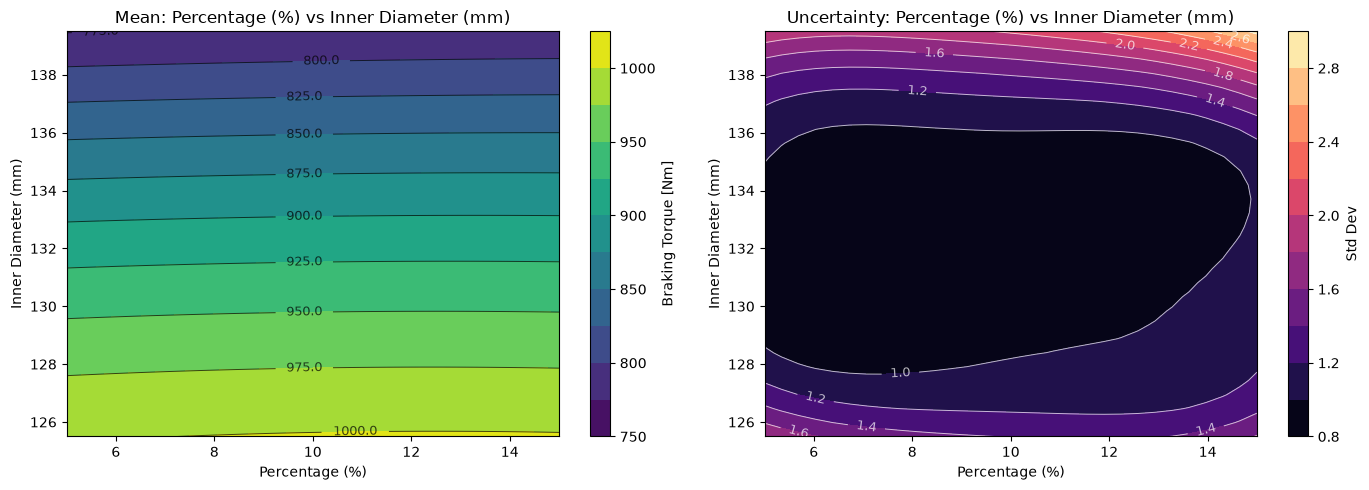

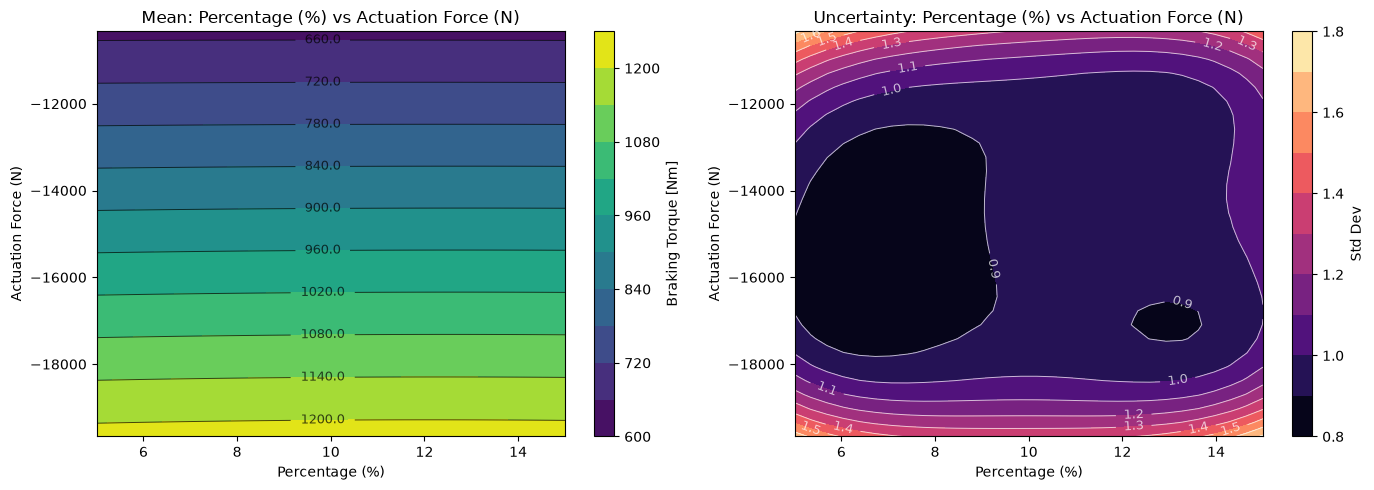

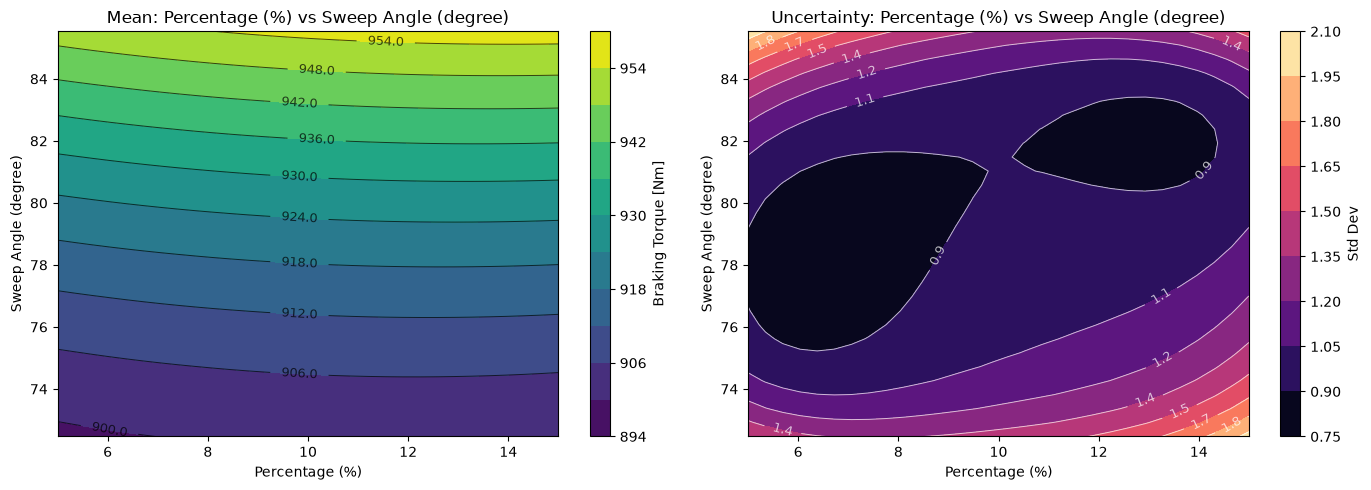

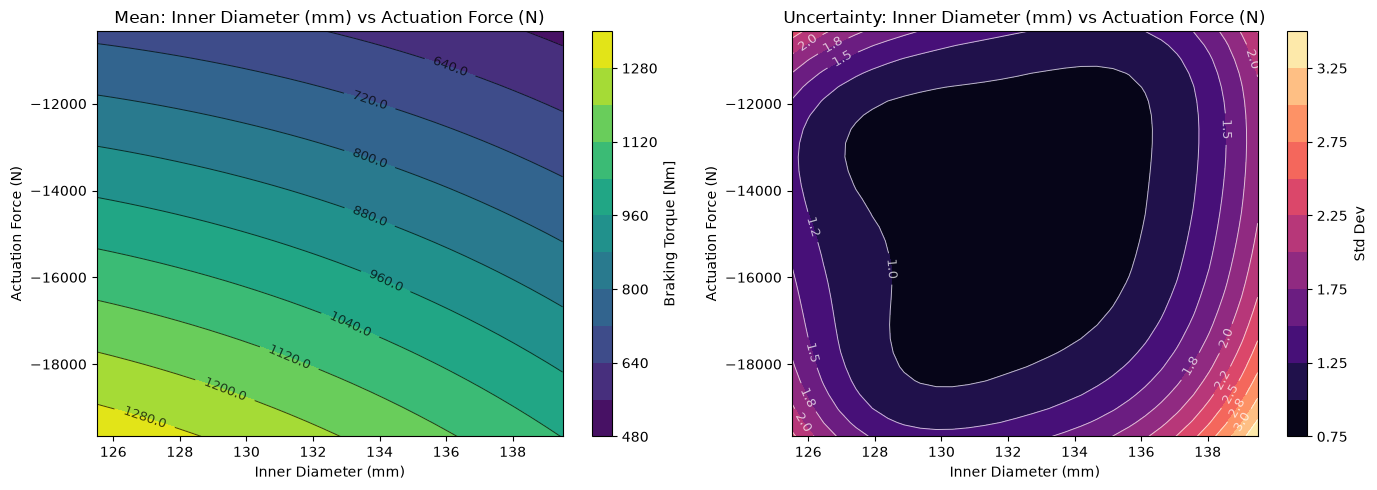

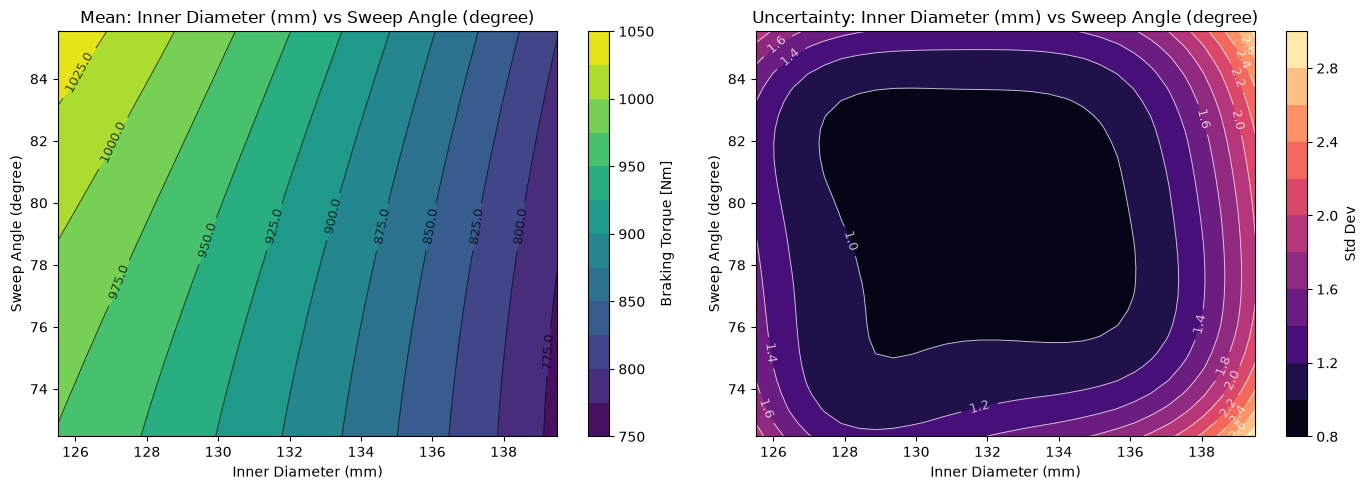

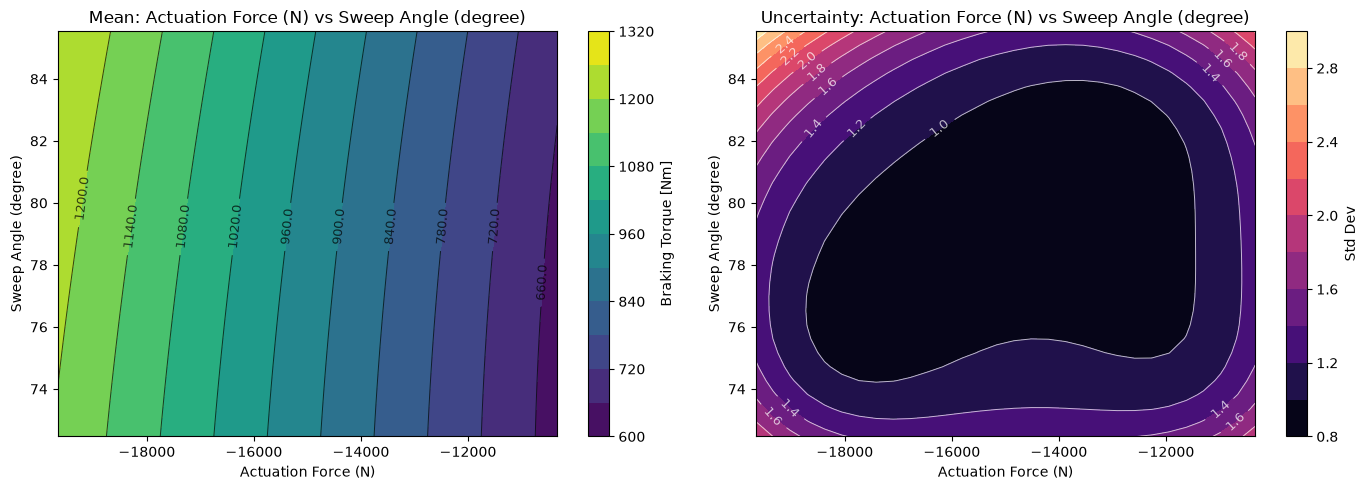

In [8]:
import itertools

features = ['percentage', 'InnerDiameter', 'ActuationForce', 'SweepAngle']
features_disp = ['Percentage (%)', 'Inner Diameter (mm)', 'Actuation Force (N)', 'Sweep Angle (degree)']
combinations = list(itertools.combinations(features, 2))
n_points = 30 # Reduced for plotting speed

#Mapping Feature and Feature_Disp
name_map=dict(zip(features,features_disp))

for feat1, feat2 in combinations:
    x1_range = np.linspace(X[feat1].min(), X[feat1].max(), n_points)
    x2_range = np.linspace(X[feat2].min(), X[feat2].max(), n_points)
    X1, X2 = np.meshgrid(x1_range, x2_range)

    # Prepare grid input with mean values for unspecified features
    grid_data = pd.DataFrame([X_train.mean()] * (n_points**2), columns=features)
    grid_data[feat1] = X1.ravel()
    grid_data[feat2] = X2.ravel()

    grid_scaled = scaler_X.transform(grid_data)
    y_mu, y_std = best_gpr.predict(grid_scaled, return_std=True)

    Z_mu = y_mu.reshape(n_points, n_points)
    Z_std = y_std.reshape(n_points, n_points)

    # Use the mapping for labels
    disp_feat1 = name_map[feat1]
    disp_feat2 = name_map[feat2]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Mean
    # 1. Contour Plot
    c1 = ax1.contourf(X1, X2, Z_mu, levels=10, cmap='viridis')
    fig.colorbar(c1, ax=ax1, label='Braking Torque [Nm]')

    # 2. Contour Line Plot
   
    lines = ax1.contour(X1, X2, Z_mu, levels=10, colors='black', linewidths=0.7, alpha=0.7)
    ax1.clabel(lines, inline=True, fontsize=9, fmt='%.1f') # fmt untuk mengatur desimal

    # 3. Label and Title
    ax1.set_title(f'Mean: {disp_feat1} vs {disp_feat2}')
    ax1.set_xlabel(disp_feat1)
    ax1.set_ylabel(disp_feat2)


    # Plot Std Dev
    c2 = ax2.contourf(X1, X2, Z_std, levels=10, cmap='magma')
    fig.colorbar(c2, ax=ax2, label='Std Dev')
    ax2.set_title(f'Uncertainty: {disp_feat1} vs {disp_feat2}')
    ax2.set_xlabel(disp_feat1)
    ax2.set_ylabel(disp_feat2)

    # Contour Line Plot Standard Deviation
       
    lines_std = ax2.contour(X1, X2, Z_std, levels=10, colors='white', linewidths=0.7, alpha=0.7)
    ax2.clabel(lines_std, inline=True, fontsize=9, fmt='%.1f')

    plt.tight_layout()
    plt.show()


### 6. Sensitivity Analysis: 1D Marginal Effects
To isolate the impact of individual design choices, we plot the predicted Braking Torque against each variable while holding all others at their mean value. The shaded **95% Confidence Interval** illustrates the model's localized reliability.
```

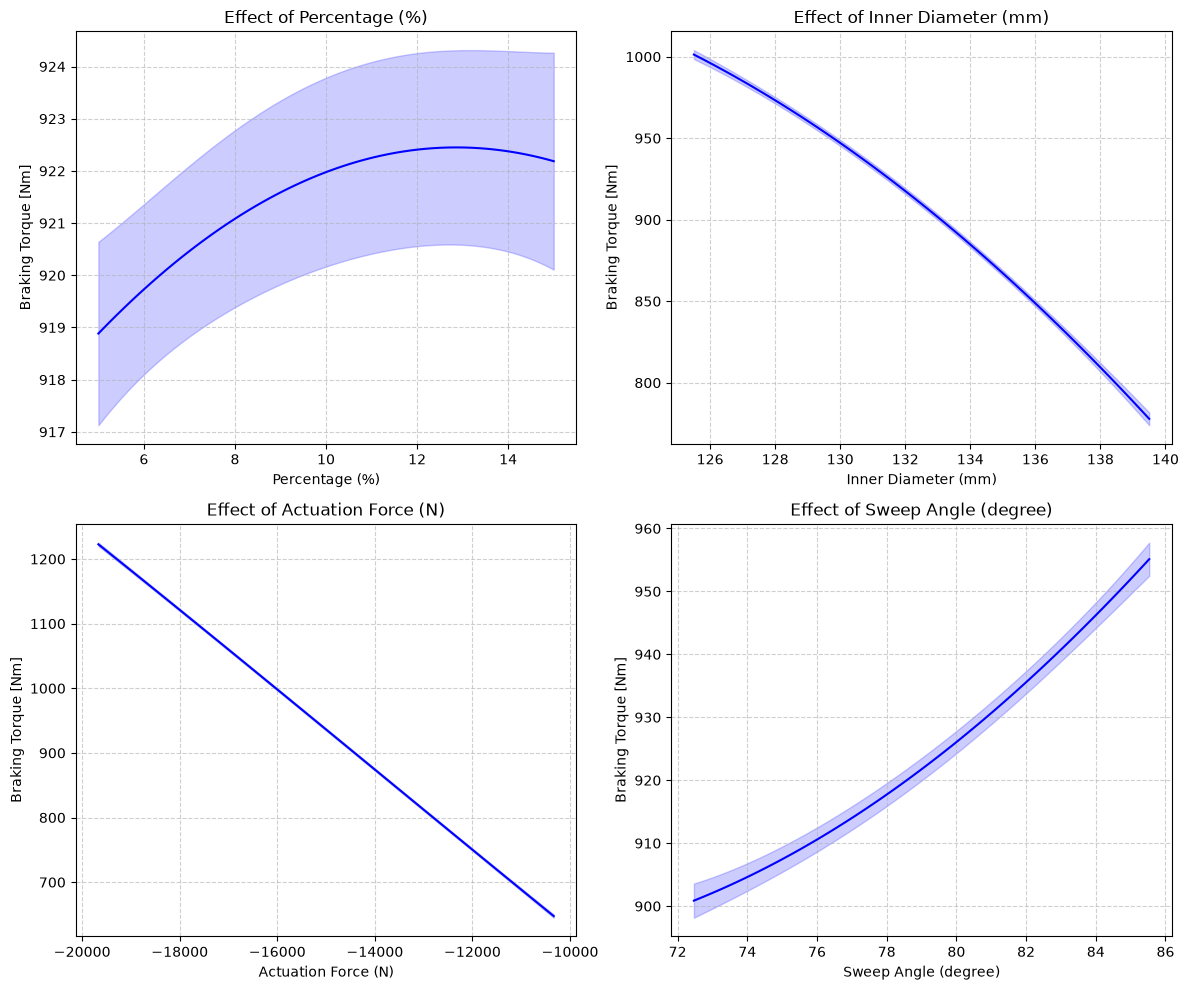

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    x_line = np.linspace(X[feature].min(), X[feature].max(), 100)
    line_data = pd.DataFrame([X_train.mean()] * 100, columns=features)
    line_data[feature] = x_line

    line_scaled = scaler_X.transform(line_data)
    y_mu, y_std = best_gpr.predict(line_scaled, return_std=True)

    disp_feature=name_map[feature]

    axes[i].plot(x_line, y_mu, color='blue', label='Mean Prediction')
    axes[i].fill_between(x_line, y_mu - 1.96*y_std, y_mu + 1.96*y_std, color='blue', alpha=0.2, label='95% CI')
    axes[i].set_title(f'Effect of {disp_feature}')
    axes[i].set_xlabel(disp_feature)
    axes[i].set_ylabel('Braking Torque [Nm]')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#print(line_data["percentage"])

### 7. Noise Sensitivity Analysis
We compare the optimized model (with small alpha) against a purely interpolating model (alpha=0) to see if the noise term improves numerical stability or overly smooths the FEA results.

In [10]:
from sklearn.metrics import mean_squared_error

# Model 1: Pure Interpolation (No Noise)
gpr_noiseless = GaussianProcessRegressor(kernel=best_gpr.kernel, alpha=0, normalize_y=True, random_state=42)
gpr_noiseless.fit(X_train_scaled, y_train)

# Model 2: Current Optimized (Small Alpha)
# best_gpr is already fitted

print(f"Noiseless Model Test R2: {gpr_noiseless.score(X_test_scaled, y_test):.6f}")
print(f"Optimized Model (alpha={best_gpr.alpha}) Test R2: {best_gpr.score(X_test_scaled, y_test):.6f}")

# Check if the noiseless model has high MSE on training (it should be near 0)
print(f"Noiseless Train MSE: {mean_squared_error(y_train, gpr_noiseless.predict(X_train_scaled)):.2e}")
print(f"Optimized Train MSE: {mean_squared_error(y_train, best_gpr.predict(X_train_scaled)):.2e}")

Noiseless Model Test R2: 0.946500
Optimized Model (alpha=0.0001) Test R2: 0.998297
Noiseless Train MSE: 2.76e-25
Optimized Train MSE: 7.59e-01


### 8. Design Optimization

We use **Differential Evolution** to identify the design configuration that maximizes the predicted braking torque. The optimization bounds are defined using the minimum and maximum observed values for each design feature.

Because `differential_evolution` minimizes an objective function, the predicted braking torque is negated. Minimizing this negative value is equivalent to maximizing the original torque.

The optimized design variables and corresponding predicted braking torque are then displayed.

In [11]:
from scipy.optimize import differential_evolution

features = ['percentage', 'InnerDiameter', 'ActuationForce', 'SweepAngle']
feature_units = {
    'percentage': '%',
    'InnerDiameter': 'mm',
    'ActuationForce': 'N',
    'SweepAngle': 'degree',
}

# Search the continuous design space bounded by the observed data.
bounds = [(X[feature].min(), X[feature].max()) for feature in features]


def objective(values):
    candidate = pd.DataFrame([values], columns=features)
    candidate_scaled = scaler_X.transform(candidate)
    predicted_torque = best_gpr.predict(candidate_scaled)[0]
    return -predicted_torque


optimization = differential_evolution(
    objective,
    bounds=bounds,
    seed=42,
    polish=True,
)

# Predict the torque and uncertainty at the best continuous candidate.
optimal_candidate = pd.DataFrame([optimization.x], columns=features)
optimal_candidate_scaled = scaler_X.transform(optimal_candidate)
torque_mean, torque_std = best_gpr.predict(
    optimal_candidate_scaled,
    return_std=True,
)

optimal_torque = float(torque_mean[0])
uncertainty = float(torque_std[0])
torque_lower = optimal_torque - 1.96 * uncertainty
torque_upper = optimal_torque + 1.96 * uncertainty
continuous_optimum = dict(zip(features, optimization.x))

# Present the recommended design in a compact, unit-aware table.
optimal_design = pd.DataFrame({
    'Parameter': features,
    'Unit': [feature_units[feature] for feature in features],
    'Lower Bound': [bound[0] for bound in bounds],
    'Optimal Value': [continuous_optimum[feature] for feature in features],
    'Upper Bound': [bound[1] for bound in bounds],
})

# Present model performance separately from the design variables.
optimization_summary = pd.DataFrame({
    'Metric': [
        'Predicted braking torque',
        'Prediction standard deviation',
        'Approximate 95% lower limit',
        'Approximate 95% upper limit',
        'Optimization successful',
    ],
    'Value': [
        f'{optimal_torque:.3f}',
        f'{uncertainty:.3f}',
        f'{torque_lower:.3f}',
        f'{torque_upper:.3f}',
        'Yes' if optimization.success else 'No',
    ],
    'Unit': ['N-m', 'N-m', 'N-m', 'N-m', ''],
})

print('Continuous optimum design')
display(optimal_design.round(3).reset_index(drop=True))

print('Optimization result')
display(optimization_summary)


Continuous optimum design


,Parameter,Unit,Lower Bound,Optimal Value,Upper Bound
0,percentage,%,5.000,11.122,15.000
1,InnerDiameter,mm,125.500,125.500,139.500
2,ActuationForce,N,-19666.667,-19638.234,-10333.333
3,SweepAngle,degree,72.467,85.533,85.533


Optimization result


,Metric,Value,Unit
0,Predicted braking torque,1374.871,N-m
1,Prediction standard deviation,3.043,N-m
2,Approximate 95% lower limit,1368.907,N-m
3,Approximate 95% upper limit,1380.836,N-m
4,Optimization successful,Yes,
